In [ ]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import plotnine as p9
import seaborn as sns
sk.set_config(transform_output="pandas")
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer


In [2]:
bank_full=pd.read_csv("/home/georgehagstrom/work/Teaching/DATA622Spring2026/website/assignments/labs/labData/bank_marketing_dataset.csv")

In [3]:
bank_full

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,...,previous,poutcome,month_numeric,year,euribor3m,emp.var.rate,nr.employed,cons.price.idx,cons.conf.idx,y
0,0,58,management,married,tertiary,no,2143,yes,no,unknown,...,0,unknown,5,2008,4.857,1.1,5191.0,93.994,-36.4,no
1,1,44,technician,single,secondary,no,29,yes,no,unknown,...,0,unknown,5,2008,4.857,1.1,5191.0,93.994,-36.4,no
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,...,0,unknown,5,2008,4.857,1.1,5191.0,93.994,-36.4,no
3,3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,...,0,unknown,5,2008,4.857,1.1,5191.0,93.994,-36.4,no
4,4,33,unknown,single,unknown,no,1,no,no,unknown,...,0,unknown,5,2008,4.857,1.1,5191.0,93.994,-36.4,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,45206,51,technician,married,tertiary,no,825,no,no,cellular,...,0,unknown,11,2010,1.047,-1.1,4963.6,94.767,-50.8,yes
45207,45207,71,retired,divorced,primary,no,1729,no,no,cellular,...,0,unknown,11,2010,1.047,-1.1,4963.6,94.767,-50.8,yes
45208,45208,72,retired,married,secondary,no,5715,no,no,cellular,...,3,success,11,2010,1.047,-1.1,4963.6,94.767,-50.8,yes
45209,45209,57,blue-collar,married,secondary,no,668,no,no,telephone,...,0,unknown,11,2010,1.047,-1.1,4963.6,94.767,-50.8,no


In [4]:
bank_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      45211 non-null  int64  
 1   age             45211 non-null  int64  
 2   job             45211 non-null  str    
 3   marital         45211 non-null  str    
 4   education       45211 non-null  str    
 5   default         45211 non-null  str    
 6   balance         45211 non-null  int64  
 7   housing         45211 non-null  str    
 8   loan            45211 non-null  str    
 9   contact         45211 non-null  str    
 10  day             45211 non-null  int64  
 11  duration        45211 non-null  int64  
 12  campaign        45211 non-null  int64  
 13  pdays           45211 non-null  int64  
 14  previous        45211 non-null  int64  
 15  poutcome        45211 non-null  str    
 16  month_numeric   45211 non-null  int64  
 17  year            45211 non-null  int64  
 1

In [72]:
bank_full["age_cat"] = pd.cut(bank_full["age"], bins=[0, 25,40,  60, np.inf], labels=False)

train_set, test_set = train_test_split(bank_full, test_size=0.2, random_state=93210,stratify=bank_full[["year","age_cat"]])

Text(0.5, 1.0, 'Age by Target')

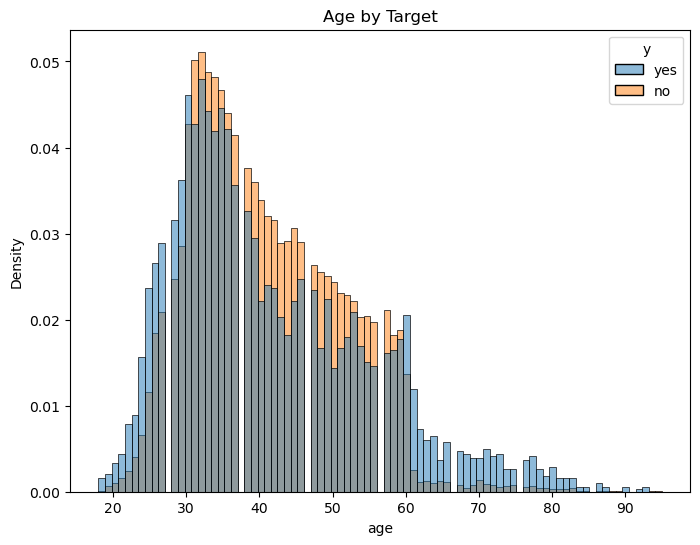

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))



sns.histplot(data=train_set, x="age", hue="y", stat="density", common_norm=False, ax=ax)
ax.set_title("Age by Target")



Text(0.5, 1.0, 'Age by Target')

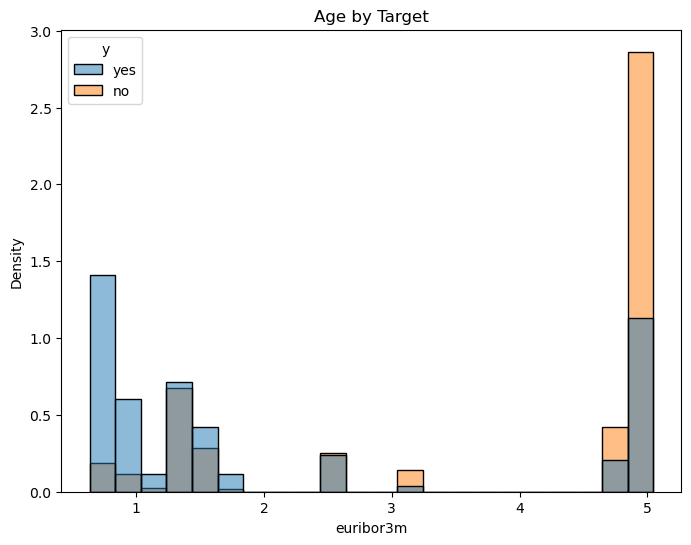

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))



sns.histplot(data=train_set, x="euribor3m", hue="y", stat="density", common_norm=False, ax=ax)
ax.set_title("Age by Target")


Text(0.5, 1.0, 'Age by Target')

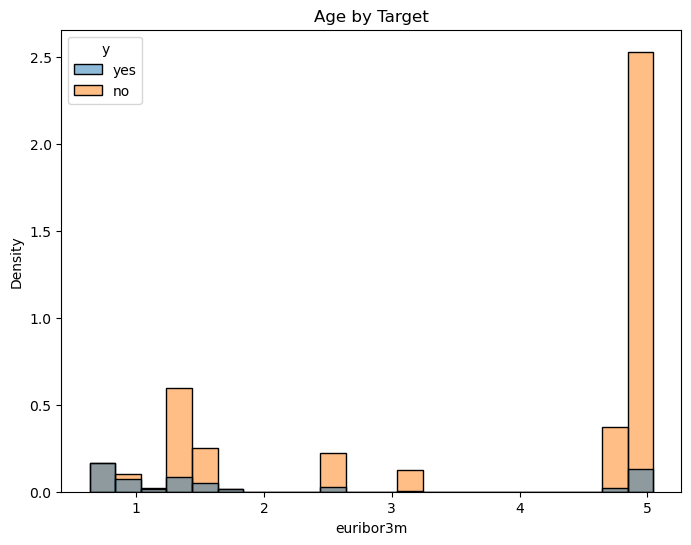

In [54]:
fig, ax = plt.subplots(figsize=(8, 6))



sns.histplot(data=train_set, x="euribor3m", hue="y", stat="density",  ax=ax)
ax.set_title("Age by Target")

In [73]:
train_set["date"] = pd.to_datetime({'year': train_set['year'], 'month': train_set['month_numeric'], 'day': train_set['day']})

In [65]:
euribor_df = (train_set.groupby('date')['euribor3m']
    .first()
    .reset_index()
)

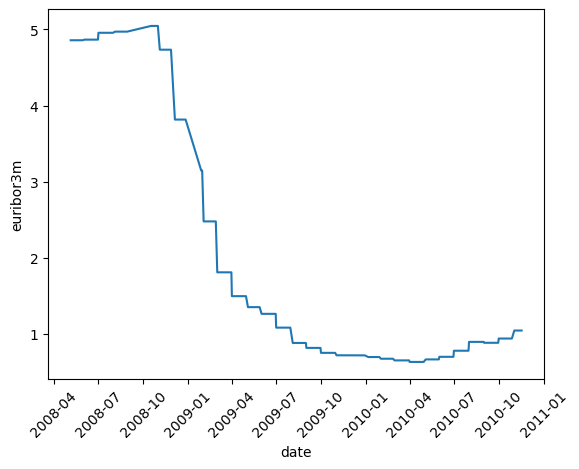

In [66]:
euribor_df = (train_set.groupby('date')[['euribor3m', 'cons.conf.idx', 'cons.price.idx','nr.employed']]
    .first()
    .reset_index()
)

sns.lineplot(data=euribor_df, x='date', y='euribor3m')
plt.xticks(rotation=45);

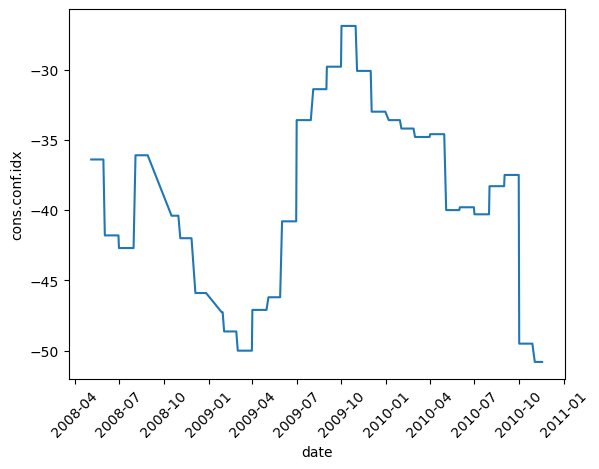

In [67]:
sns.lineplot(data=euribor_df, x='date', y='cons.conf.idx')
plt.xticks(rotation=45);

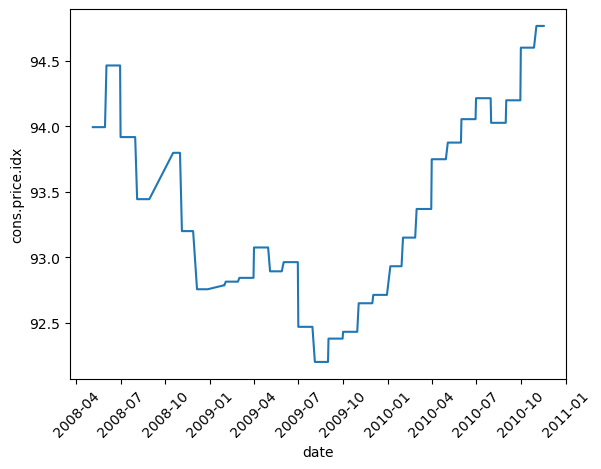

In [25]:
sns.lineplot(data=euribor_df, x='date', y='cons.price.idx')
plt.xticks(rotation=45);

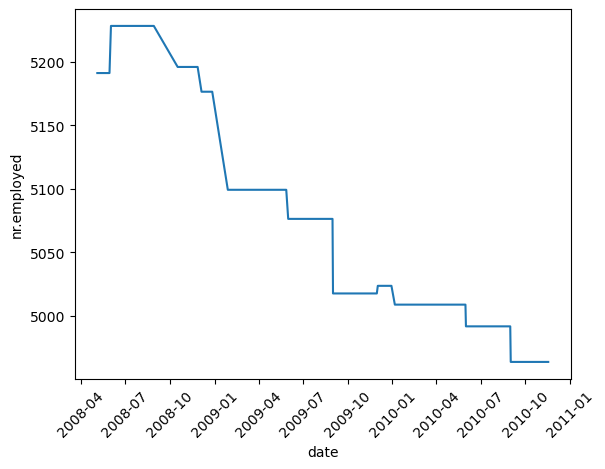

In [26]:
sns.lineplot(data=euribor_df, x='date', y='nr.employed')
plt.xticks(rotation=45);

In [68]:
euribor_df = euribor_df.sort_values('date')

euribor_df["cpi_lag_90"] = np.interp(
    (euribor_df['date']-pd.Timedelta(days=90)).astype(int),
    euribor_df['date'].index.astype(int),
    euribor_df["cons.price.idx"]
    )

euribor_df["inflation_3m"] = (euribor_df["cons.price.idx"]/euribor_df['cpi_lag_90'])**(365 / 90.0)-1

In [41]:
(euribor_df["cons.price.idx"]/euribor_df['cpi_lag_90'])**(365.0/90.0)-1

date
2008-05-05    0.000000
2008-05-06    0.000000
2008-05-07    0.000000
2008-05-08    0.000000
2008-05-09    0.000000
                ...   
2010-11-11    0.032303
2010-11-12    0.032303
2010-11-15    0.032303
2010-11-16    0.032303
2010-11-17    0.032303
Length: 556, dtype: float64

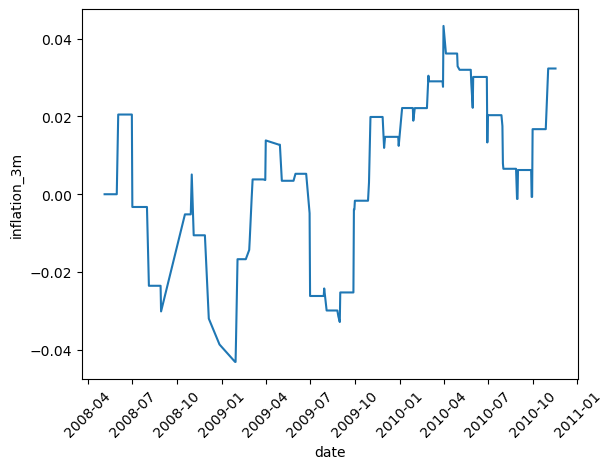

In [43]:
sns.lineplot(data=euribor_df, x='date', y='inflation_3m')
plt.xticks(rotation=45);

In [74]:
inflation_df = euribor_df[["date","inflation_3m"]]


train_set = train_set.merge(inflation_df,on="date")
test_set["date"] = pd.to_datetime({'year': test_set['year'], 'month': test_set['month_numeric'], 'day': test_set['day']})
test_set = test_set.merge(inflation_df,on="date")

In [75]:
test_set

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,...,year,euribor3m,emp.var.rate,nr.employed,cons.price.idx,cons.conf.idx,y,age_cat,date,inflation_3m
0,25059,55,technician,single,secondary,no,2043,yes,no,cellular,...,2008,4.733,-0.1,5195.8,93.200,-42.0,no,2,2008-11-18,-0.065385
1,9678,54,self-employed,divorced,tertiary,no,3952,no,no,unknown,...,2008,4.865,1.4,5228.1,94.465,-41.8,no,2,2008-06-06,-0.012861
2,23205,35,technician,divorced,secondary,no,1085,no,no,cellular,...,2008,4.970,1.4,5228.1,93.444,-36.1,no,1,2008-08-27,-0.055422
3,17726,45,services,married,secondary,no,-158,yes,no,telephone,...,2008,4.955,1.4,5228.1,93.918,-42.7,no,2,2008-07-29,-0.035839
4,945,33,admin.,married,secondary,no,-6,yes,no,unknown,...,2008,4.857,1.1,5191.0,93.994,-36.4,no,1,2008-05-07,-0.032671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9029,7927,37,admin.,married,secondary,no,-47,yes,no,unknown,...,2008,4.857,1.1,5191.0,93.994,-36.4,no,1,2008-05-30,-0.032671
9030,19525,52,management,married,tertiary,no,0,no,no,cellular,...,2008,4.970,1.4,5228.1,93.444,-36.1,no,2,2008-08-07,-0.055422
9031,39892,50,blue-collar,married,primary,no,3764,no,no,telephone,...,2009,1.266,-2.9,5076.2,92.963,-40.8,no,2,2009-06-02,-0.074986
9032,24921,41,entrepreneur,married,secondary,no,8491,yes,no,cellular,...,2008,4.733,-0.1,5195.8,93.200,-42.0,yes,2,2008-11-18,-0.065385


Text(0.5, 1.0, 'Age by Target')

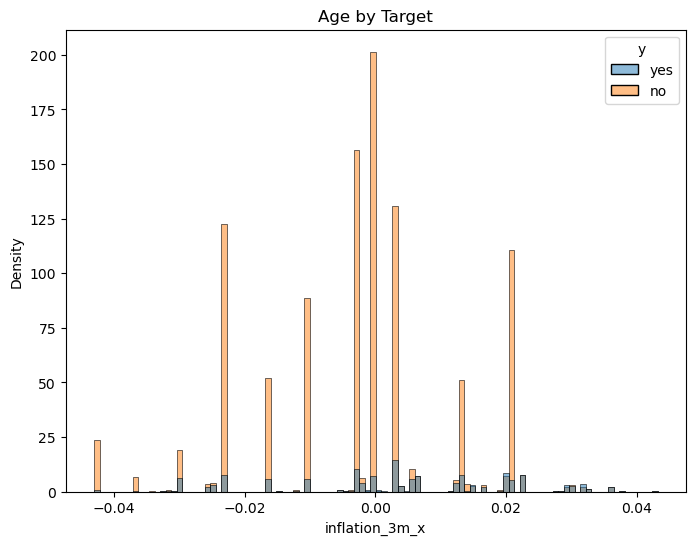

In [53]:
fig, ax = plt.subplots(figsize=(8, 6))



sns.histplot(data=train_set, x="inflation_3m_x", hue="y", stat="density", ax=ax)
ax.set_title("Age by Target")


Text(0.5, 1.0, 'Age by Target')

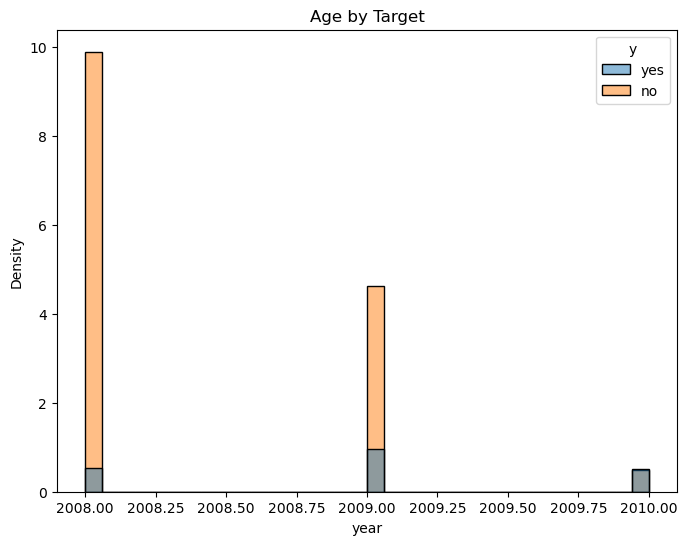

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))



sns.histplot(data=train_set, x="year", hue="y", stat="density",  ax=ax)
ax.set_title("Age by Target")


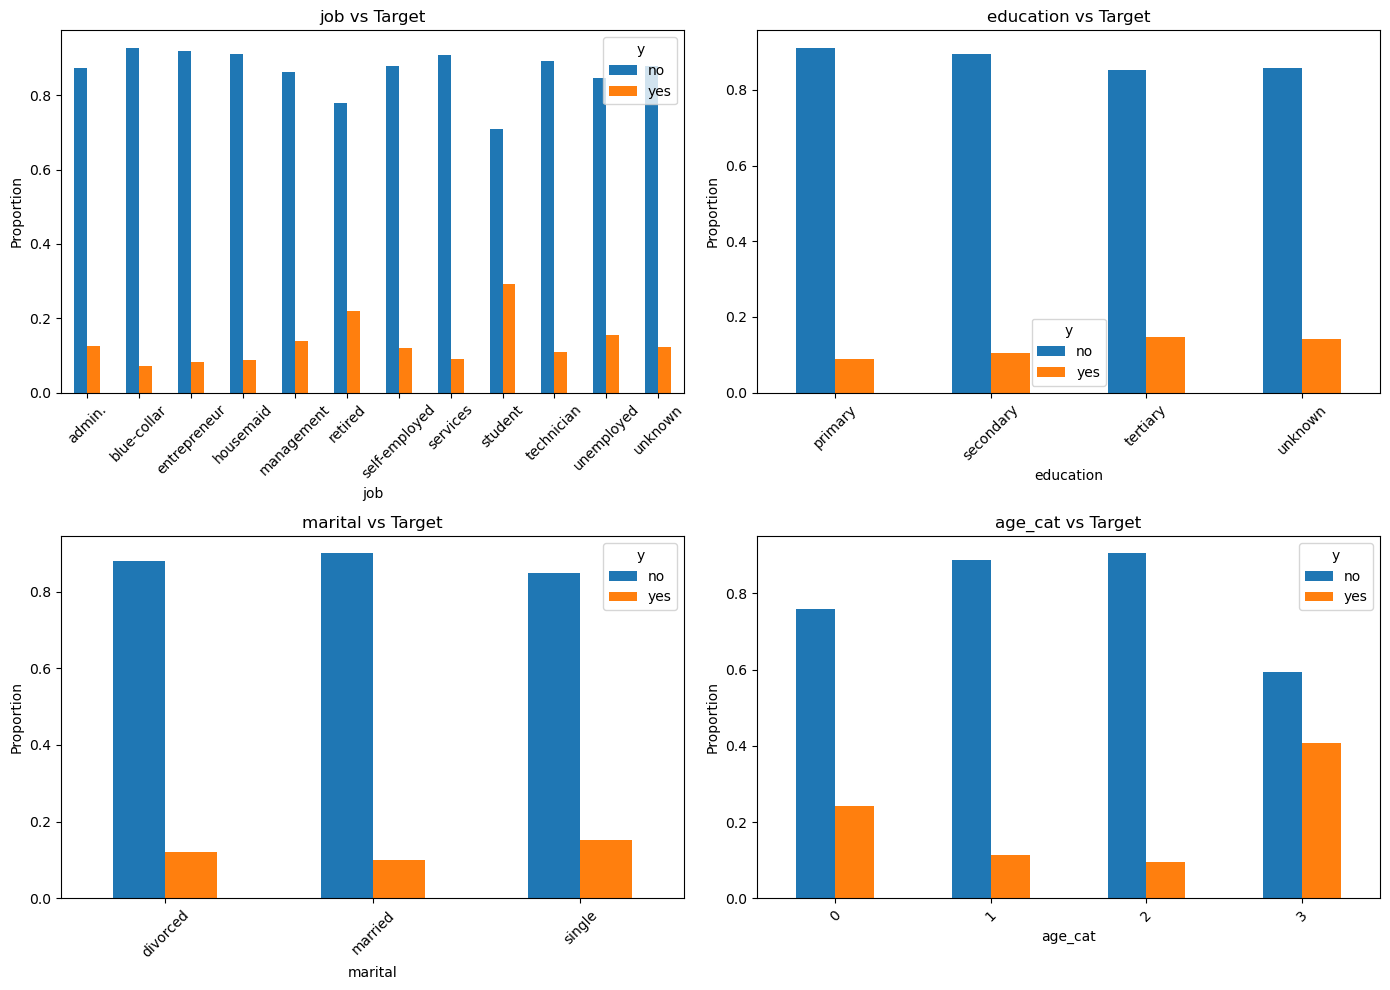

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), ["job", "education", "marital", "age_cat"]):
    pd.crosstab(train_set[col], train_set["y"], normalize="index").plot(kind="bar", ax=ax)
    ax.set_title(f"{col} vs Target")
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
euribor_df = (train_set.groupby('date')['euribor3m']
    .first()
    .reset_index()
)

sns.lineplot(data=euribor_df, x='date', y='euribor3m')
plt.xticks(rotation=45);

In [62]:
test_set

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,...,cons.conf.idx_x,y,age_cat,date,euribor3m_y,cons.conf.idx_y,cons.price.idx_y,nr.employed_y,cpi_lag_90,inflation_3m
0,25059,55,technician,single,secondary,no,2043,yes,no,cellular,...,-42.0,no,2,2008-11-18,4.733,-42.0,93.200,5195.8,93.444,-0.010548
1,9678,54,self-employed,divorced,tertiary,no,3952,no,no,unknown,...,-41.8,no,2,2008-06-06,4.865,-41.8,94.465,5228.1,93.994,0.020478
2,23205,35,technician,divorced,secondary,no,1085,no,no,cellular,...,-36.1,no,1,2008-08-27,4.970,-36.1,93.444,5228.1,93.994,-0.023520
3,17726,45,services,married,secondary,no,-158,yes,no,telephone,...,-42.7,no,2,2008-07-29,4.955,-42.7,93.918,5228.1,93.994,-0.003275
4,945,33,admin.,married,secondary,no,-6,yes,no,unknown,...,-36.4,no,1,2008-05-07,4.857,-36.4,93.994,5191.0,93.994,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9029,7927,37,admin.,married,secondary,no,-47,yes,no,unknown,...,-36.4,no,1,2008-05-30,4.857,-36.4,93.994,5191.0,93.994,0.000000
9030,19525,52,management,married,tertiary,no,0,no,no,cellular,...,-36.1,no,2,2008-08-07,4.970,-36.1,93.444,5228.1,93.994,-0.023520
9031,39892,50,blue-collar,married,primary,no,3764,no,no,telephone,...,-40.8,no,2,2009-06-02,1.266,-40.8,92.963,5076.2,92.843,0.005252
9032,24921,41,entrepreneur,married,secondary,no,8491,yes,no,cellular,...,-42.0,yes,2,2008-11-18,4.733,-42.0,93.200,5195.8,93.444,-0.010548


In [76]:

train_set_target = train_set["y"].copy()
test_set_target = test_set["y"].copy()
train_set_drop = train_set.copy().drop(["duration","y","year","day","month_numeric","cons.price.idx"],axis=1)
test_set_drop = test_set.copy().drop(["duration","y","year","day","month_numeric","cons.price.idx"],axis=1)

In [77]:

num_nb= ['age',  'campaign', 'pdays',
          'euribor3m', 'emp.var.rate', 'nr.employed',
          'inflation_3m', 'cons.conf.idx']
cat_nb = ['marital', 'education', 'default',
          'housing', 'loan', 'contact', 'poutcome', 'housing_loan']

In [79]:

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_nb),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), 
     cat_nb)
])



In [80]:
# Quick guide to this code

# BaseEstimator and ClassifierMixin are two classes in Sklearn. 
# BaseEstimator is a general Sklearn model
# mixin is a term from software engineering, refers to a class that
# mixes in one additional feature. The model we are creating is a
# classification model so it will inherit a classification
# score method from classifier mixin. This specifies that we are making a 
# classification model. There is also a RegressorMixin that we would use instead if we were doing regression

class NaiveBayes_Hybrid(BaseEstimator, ClassifierMixin):
    # We always need an init method
    def __init__(self, numeric_features):
        # We are going to have a Gaussian Naive Bayes model for the
        # continuous features and a Categorical one for the categorical
        # features. We create them when we initialize
        
        # We use this to split the features into Numerical and Categorical
        self.n = len(numeric_features)


        self.gnb = GaussianNB()
        self.cnb = CategoricalNB()
    
    # sklearn models can have a variety of methods (check out their source code to learn more)
    # The naive bayes models have a class, but it has more methods than we want here
    # so we don't want to try it
    
    # This is the function that does the fitting. We are going to basically
    # split the categorical and numerical variables and feed each to the appropriate
    # naive Bayes

    def fit(self, X, y):

        # These are what we will predict
        # This is a standard feature of all the fit methods
        self.classes_ = np.unique(y)
        
        # From our preprocessor, the numerical features come first

        X_num = X[:, :self.n]
        X_cat = X[:, self.n:]

        # Now we fit the Gaussian Naive Bayes and
        # the categorical naive bayes

        self.gnb.fit(X_num, y)
        self.cnb.fit(X_cat, y)

        # We always return self, which lets us fit and then do otherstuff in the same
        # pipeline
        return self
    
    # We will predict some probabilities so we can show the awful model calibration

    def predict_proba(self, X):

        # Same deal with splitting

        X_num = X[:, :self.n]
        X_cat = X[:, self.n:]

        # We could also have a predict_log_proba method and if we wanted this to
        # be more useful we would

        # We get the log probability from our gnb and cnb models
        # Then we need to subtract off one of the priors because
        # each of the gnb and cnb are going to use the prior

        log_prob = (self.gnb.predict_log_proba(X_num) 
                    + self.cnb.predict_log_proba(X_cat)
                    - np.log(self.gnb.class_prior_))  
        
        # Normalize to probabilities        
        prob = np.exp(log_prob)
        return prob / prob.sum(axis=1, keepdims=True)
    
    # We predict by finding the probabilities of each class and taking the max

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), 
     categorical_features)
])

pipe_nb = Pipeline([
    ('prep', preprocessor),
    ('model', NaiveBayes_Hybrid())
])

NameError: name 'ClassifierMixin' is not defined